# K-Means Clustering on the Country Dataset

Take the existing Iris dataset, and adapt it to the Country dataset from Wikidata

In [1]:
%pip install -q matplotlib numpy scikit-learn

print('Packages installed.')

Note: you may need to restart the kernel to use updated packages.
Packages installed.


## Imports and setup

The script uses the built-in Iris dataset from `scikit-learn`, and the standard plotting utilities for a quick visual check.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

np.random.seed(42)

print('Libraries imported.')

Libraries imported.


## Load the dataset and evaluate the elbow

We test a range of cluster counts from 1 to 10 and inspect the inertia values. The elbow point is a heuristic signal for choosing a reasonable `k`.

In [3]:
#from google.colab import drive
import os
import pandas as pd
#drive.mount('/content/drive')
from pathlib import Path

DATA_PATH = Path("../../data") / "wikidata_country_numerical.csv"
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f'File not found in Drive: {DATA_PATH}. Update DATA_PATH to match your file path.')
df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df)} rows of data.')
print(f"df.head {df.head()}")

print(f"missing values: {df.isna().sum()}")
df = df.dropna()
# print(f"missing values: {df.isna().sum()}")


Loaded 200 rows of data.
df.head                                country countryLabel         pop    areaKm2  \
0  http://www.wikidata.org/entity/Q889  Afghanistan  41454761.0   652230.0   
1  http://www.wikidata.org/entity/Q222      Albania   2811655.0    28748.0   
2  http://www.wikidata.org/entity/Q262      Algeria  46164219.0  2381741.0   
3  http://www.wikidata.org/entity/Q228      Andorra     89752.0      468.0   
4  http://www.wikidata.org/entity/Q916       Angola  36749906.0  1246700.0   

         gdpUSD  lifeExp  
0  2.049713e+10   63.673  
1  2.354718e+10   78.345  
2  1.919129e+11   77.130  
3  3.352033e+09      NaN  
4  1.359668e+11   61.547  
missing values: country          0
countryLabel     0
pop              1
areaKm2          1
gdpUSD          14
lifeExp         10
dtype: int64


### transform the data to work with Kmeans

In [4]:
# make a copy of the df called df_copy, so we can transform it
df_copy = df.copy()

# normalize all numerical values for columns 2-5 to a number between 0-1 based on the min and max values
for i in range(2, 6):
    df_copy.iloc[:, i] = (df_copy.iloc[:, i] - df_copy.iloc[:, i].min()) / (df_copy.iloc[:, i].max() - df_copy.iloc[:, i].min())

print(f"df_copy.head {df_copy.head()}")

df_copy.head                                country         countryLabel       pop  \
0  http://www.wikidata.org/entity/Q889          Afghanistan  0.029500   
1  http://www.wikidata.org/entity/Q222              Albania  0.001994   
2  http://www.wikidata.org/entity/Q262              Algeria  0.032852   
4  http://www.wikidata.org/entity/Q916               Angola  0.026151   
5  http://www.wikidata.org/entity/Q781  Antigua and Barbuda  0.000065   

    areaKm2    gdpUSD   lifeExp  
0  0.038196  0.000711  0.352510  
1  0.001683  0.000817  0.789409  
2  0.139483  0.006673  0.753229  
4  0.073011  0.004727  0.289202  
5  0.000025  0.000059  0.808914  


### Isolate the features and store indexes for future reconstruction

In [5]:
# defining the columns to be used in clustering
clustering_features = ["pop", "areaKm2", "gdpUSD", "lifeExp"]

# created features_df from df_copy with only clustering_features
features_df = df_copy[clustering_features]

# convert features_df to numpy and assign to variabe X
X = features_df.to_numpy()

# Store the index of the features data so we can map back later
original_indices_for_X = features_df.index.values

print(f"X.shape {X.shape}")
print(f"original_indices_for_X {original_indices_for_X}")

X.shape (181, 4)
original_indices_for_X [  0   1   2   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  39  40  41  42  43  44  45  46  47  48  50  51  52  53  54  55  56
  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74
  76  77  78  79  80  81  82  83  87  89  90  91  92  93  94  95  96  97
  98  99 100 101 102 103 104 105 106 107 108 109 110 112 113 114 115 116
 117 118 119 120 121 122 123 125 126 127 128 129 130 131 132 133 134 135
 136 137 139 140 141 142 143 145 146 147 148 149 150 151 152 153 154 155
 156 157 158 159 160 161 162 164 165 166 167 168 169 171 173 174 175 176
 177 178 179 180 181 182 183 185 186 187 188 189 190 191 192 193 196 198
 199]


In [17]:
# Set your k value
# For this dataset, the correct k is 3
k = 6

# Load the Iris dataset
# iris = load_iris()
# X = iris.data  # Using all 4 features: sepal/petal length and width
# don't need this, X is defined above

# Calculate inertia for the Elbow Method (k from 1 to 10)
inertia = []
k_range = range(1, 11)

for k_value in k_range:
    kmeans = KMeans(n_clusters=k_value, random_state=42, n_init='auto')
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

print('Inertia values for k = 1 to 10:')
for k_value, score in zip(k_range, inertia):
    print(f'k={k_value}: inertia={score:.2f}')

Inertia values for k = 1 to 10:
k=1: inertia=15.65
k=2: inertia=12.44
k=3: inertia=7.25
k=4: inertia=4.38
k=5: inertia=2.94
k=6: inertia=2.42
k=7: inertia=1.90
k=8: inertia=1.54
k=9: inertia=1.24
k=10: inertia=1.04


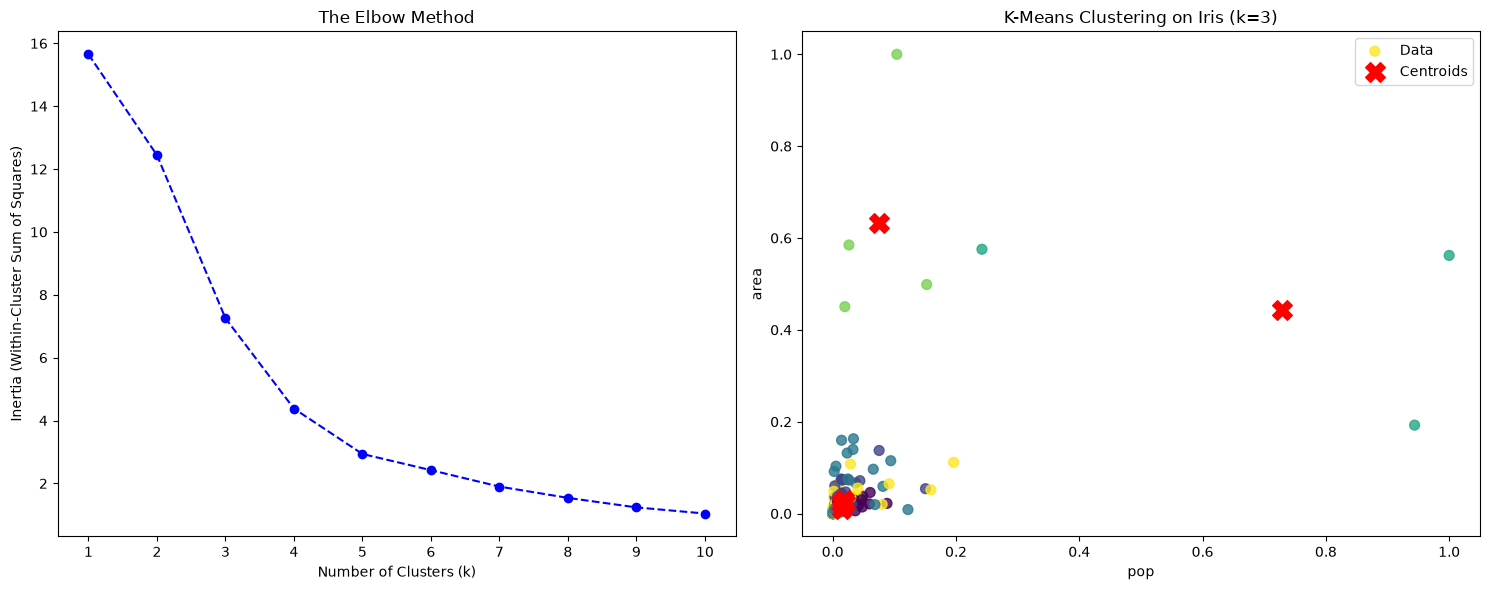

In [18]:
# Visualize the elbow plot and final cluster results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Elbow plot
ax1.plot(k_range, inertia, marker='o', linestyle='--', color='b')
ax1.set_title('The Elbow Method')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax1.set_xticks(k_range)

# Fit the final model using the chosen k value
final_kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
y_kmeans = final_kmeans.fit_predict(X)

# Plot the first two features (Sepal Length vs Sepal Width)
ax2.scatter(
    X[:, 0],
    X[:, 1],
    c=y_kmeans,
    s=50,
    cmap='viridis',
    alpha=0.8,
    label='Data'
)

# Plot centroids
centroids = final_kmeans.cluster_centers_
ax2.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)

ax2.set_title('K-Means Clustering on Iris (k=3)')
ax2.set_xlabel("pop")
ax2.set_ylabel("area")
ax2.legend()

plt.tight_layout()
plt.show()

## Final cluster output

The final section prints the actual grouped points by cluster so you can inspect the results from the model.

In [19]:
print('Final K-Means Clustering Results:')
for i in range(k):
    cluster_points = X[y_kmeans == i]
    print(f'\nCluster {i + 1}:')
    print(cluster_points)
    print(f'Type of first point in cluster {i + 1}: {type(cluster_points[0])}')

Final K-Means Clustering Results:

Cluster 1:
[[1.99377405e-03 1.68300695e-03 8.16907780e-04 7.89409349e-01]
 [6.46646273e-05 2.51994244e-05 5.90330933e-05 8.08913804e-01]
 [6.38435675e-03 4.91168811e-03 1.77950927e-02 8.68469395e-01]
 [2.08407931e-04 2.51238771e-05 1.93996221e-04 7.79136009e-01]
 [8.40990932e-03 1.79662075e-03 2.24244285e-02 8.89016073e-01]
 [1.38427239e-02 4.42796329e-02 1.10136822e-02 8.38691599e-01]
 [3.74048631e-03 2.99670579e-03 2.37629079e-03 8.33659152e-01]
 [2.74841393e-03 3.31377497e-03 2.46615819e-03 7.79136009e-01]
 [9.49784758e-04 5.40687504e-04 9.87054580e-04 8.53818719e-01]
 [7.75785974e-03 4.61840110e-03 8.71696842e-03 8.08913804e-01]
 [1.20496774e-02 1.50622779e-02 3.99949718e-03 7.79136009e-01]
 [9.67593405e-04 2.65440497e-03 1.32310533e-03 7.79136009e-01]
 [4.01617261e-03 1.98219976e-02 1.03067146e-02 8.74424954e-01]
 [4.88262374e-02 3.77028577e-02 9.67915921e-02 8.98247190e-01]
 [5.94047265e-02 2.09411188e-02 1.43339522e-01 8.95269410e-01]
 [7.45390

### Cluster Assignments

In [20]:
df_copy["cluster"] = np.nan

print("y_kmeans\n", y_kmeans)
print("original_indices_for_X\n", original_indices_for_X)

# Assign the cluster labels to the original DataFrame
df_copy.loc[original_indices_for_X, "cluster"] = y_kmeans
df_copy

y_kmeans
 [5 0 2 1 0 2 2 4 0 2 2 2 0 2 0 5 1 2 5 2 5 4 2 2 1 1 5 1 4 2 1 1 0 2 5 0 0
 0 0 1 1 2 2 0 2 2 1 0 1 5 5 5 0 0 5 2 0 1 0 2 2 1 1 5 1 2 2 0 3 5 2 5 0 0
 1 5 0 2 2 5 5 2 5 5 2 0 1 1 2 0 2 0 5 1 2 2 1 0 5 1 2 2 2 2 2 2 1 5 5 5 2
 0 2 1 1 2 0 2 5 5 2 2 5 5 3 2 5 2 0 0 5 2 4 5 2 5 2 2 0 2 5 2 2 1 0 2 0 5
 1 1 0 0 2 5 5 0 0 5 5 5 0 2 1 5 1 2 5 2 0 5 1 5 2 0 3 2 2 2 2 1 1]
original_indices_for_X
 [  0   1   2   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  39  40  41  42  43  44  45  46  47  48  50  51  52  53  54  55  56
  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74
  76  77  78  79  80  81  82  83  87  89  90  91  92  93  94  95  96  97
  98  99 100 101 102 103 104 105 106 107 108 109 110 112 113 114 115 116
 117 118 119 120 121 122 123 125 126 127 128 129 130 131 132 133 134 135
 136 137 139 140 141 142 143 145 146 147 148 149 150 151 152 153 154 155
 156 157 158 1

,country,countryLabel,pop,areaKm2,gdpUSD,lifeExp,cluster
0,http://www.wikidata.org/entity/Q889,Afghanistan,0.029500,0.038196,0.000711,0.352510,5.0
1,http://www.wikidata.org/entity/Q222,Albania,0.001994,0.001683,0.000817,0.789409,0.0
2,http://www.wikidata.org/entity/Q262,Algeria,0.032852,0.139483,0.006673,0.753229,2.0
4,http://www.wikidata.org/entity/Q916,Angola,0.026151,0.073011,0.004727,0.289202,1.0
5,http://www.wikidata.org/entity/Q781,Antigua and Barbuda,0.000065,0.000025,0.000059,0.808914,0.0
...,...,...,...,...,...,...,...
192,http://www.wikidata.org/entity/Q265,Uzbekistan,0.024845,0.026293,0.002406,0.600469,2.0
193,http://www.wikidata.org/entity/Q686,Vanuatu,0.000206,0.000713,0.000032,0.604430,2.0
196,http://www.wikidata.org/entity/Q881,Vietnam,0.068474,0.019424,0.014217,0.727114,2.0
198,http://www.wikidata.org/entity/Q953,Zambia,0.013951,0.044076,0.001034,0.298939,1.0


In [21]:
for i in range(k):
    cluster_points = df_copy[df_copy["cluster"] == i]
    cluster_points_df = pd.DataFrame(cluster_points)
    print(f"Cluster {i} has {len(cluster_points)} points.")
    print(df_copy[['countryLabel', 'cluster']])

Cluster 0 has 38 points.
            countryLabel  cluster
0            Afghanistan      5.0
1                Albania      0.0
2                Algeria      2.0
4                 Angola      1.0
5    Antigua and Barbuda      0.0
..                   ...      ...
192           Uzbekistan      2.0
193              Vanuatu      2.0
196              Vietnam      2.0
198               Zambia      1.0
199             Zimbabwe      1.0

[181 rows x 2 columns]
Cluster 1 has 32 points.
            countryLabel  cluster
0            Afghanistan      5.0
1                Albania      0.0
2                Algeria      2.0
4                 Angola      1.0
5    Antigua and Barbuda      0.0
..                   ...      ...
192           Uzbekistan      2.0
193              Vanuatu      2.0
196              Vietnam      2.0
198               Zambia      1.0
199             Zimbabwe      1.0

[181 rows x 2 columns]
Cluster 2 has 62 points.
            countryLabel  cluster
0            Afghanistan   